In [5]:
table_name = "const_vdv_rich.tsv"
table_link = f"https://cdn.lazarev.fun/data/{table_name}"
import requests
response = requests.get(table_link)
table_str = response.content.decode("utf-8")

from pathlib import Path
table_path = Path(f"/drive/data/{table_name}")
table_path.write_text(table_str)

import pandas as pd
vdv_const_rich = pd.read_csv(table_path, sep="\t")

In [4]:
vdv_const_rich.head(1)

,Substance,Formula,Const_a,Const_b,Mol_weight,Volume,cid,elements,atoms,bonds,...,cactvs_fingerprint,heavy_atom_count,isotope_atom_count,atom_stereo_count,defined_atom_stereo_count,undefined_atom_stereo_count,bond_stereo_count,defined_bond_stereo_count,undefined_bond_stereo_count,covalent_unit_count
0,Азот,N2,0.137,38.7,28.014,2.998428,947,"['N', 'N']","[{'aid': 1, 'number': 7, 'element': 'N', 'x': ...","[{'aid1': 1, 'aid2': 2, 'order': 3}]",...,0000000000000011000000000000000000000000000000...,2,0,0,0,0,0,0,0,1


In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
reg = LinearRegression()
reg.fit(
    vdv_const_rich.drop(columns=["Mol_weight"]) \
    vdv_const_rich["Mol_weight"]
)

<class 'ValueError'>: could not convert string to float: 'Азот'

In [10]:
reg = LinearRegression()
reg.fit(
    vdv_const_rich \
        .drop(columns=["Mol_weight"]) \
        .select_dtypes(include="number"),
    vdv_const_rich["Mol_weight"]
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
vdv_const_rich.select_dtypes(include="number").head(1)

,Const_a,Const_b,Mol_weight,Volume,cid,charge,molecular_weight,exact_mass,monoisotopic_mass,tpsa,...,rotatable_bond_count,heavy_atom_count,isotope_atom_count,atom_stereo_count,defined_atom_stereo_count,undefined_atom_stereo_count,bond_stereo_count,defined_bond_stereo_count,undefined_bond_stereo_count,covalent_unit_count
0,0.137,38.7,28.014,2.998428,947,0,28.014,28.006148,28.006148,47.6,...,0,2,0,0,0,0,0,0,0,1


In [14]:
reg.coef_[:5]

array([-4.69141391e-13,  6.72378819e-15,  1.68626235e-14,  3.81639165e-16,
        2.54102295e-14])

In [15]:
print(*reg.coef_, sep="\n")

-4.691413906218835e-13
6.723788192886104e-15
1.6862623493721363e-14
3.8163916471489756e-16
2.541022947610827e-14
1.0000000000000466
9.510621457042845e-15
-5.705939193356713e-14
4.234649740239571e-15
7.57418216687511e-15
5.5642453196543505e-14
-8.33186296377627e-14
1.6366578976952616e-14
-1.3504239501811732e-14
2.883410000001017
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [22]:
reg = LinearRegression()
reg.fit(
    vdv_const_rich \
        .drop(columns=["Mol_weight"]) \
        .select_dtypes(include="number"),
    vdv_const_rich["Mol_weight"]
)
vdv_const_numbers = vdv_const_rich \
    .drop(columns=["Mol_weight"]) \
    .select_dtypes(include="number")

coeff_columns = pd.Series(
    reg.coef_,
    index=vdv_const_numbers.columns
)
coeff_columns[coeff_columns > 1e-8]

molecular_weight      1.00000
isotope_atom_count    2.88341
dtype: float64

In [24]:
vdv_const_numbers.isotope_atom_count    

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    1
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
Name: isotope_atom_count, dtype: int64

In [25]:
vdv_const_numbers = vdv_const_rich \
    .drop(columns=[
        "Mol_weight", 
        "molecular_weight", 
        "isotope_atom_count"
    ]) \
    .select_dtypes(include="number")
reg.fit(
    vdv_const_numbers,
    vdv_const_rich["Mol_weight"]
)
coeff_columns = pd.Series(
    reg.coef_,
    index=vdv_const_numbers.columns
)
coeff_columns[coeff_columns > 1e-8]

Const_a              2.113766
Volume               0.056803
cid                  0.000008
exact_mass           0.299852
monoisotopic_mass    0.696556
complexity           0.012420
heavy_atom_count     0.208812
dtype: float64

In [28]:
vdv_const_numbers = vdv_const_rich.select_dtypes(include="number")
vdv_const_numbers.shape

(30, 23)

In [32]:
from sklearn.decomposition import PCA
pca = PCA(n_components=23)
pca.fit(vdv_const_numbers)
pca.explained_variance_ratio_
print(*pca.explained_variance_ratio_, sep="\n")

0.9999708624064215
2.5334676924692256e-05
1.9661348152363157e-06
1.3307062285690238e-06
4.972454257066936e-07
4.24133315646468e-09
1.559258924925299e-09
1.4032830315175799e-09
7.184415300846891e-10
4.089331285754282e-10
2.717539675277209e-10
1.256876991996346e-10
7.571832728814314e-11
2.5774508644255375e-11
4.3477119820856605e-35
5.233078963634813e-39
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [34]:
import numpy as np
np.array([-4, -3, 0, 1, 5]) / 5 

array([-0.8, -0.6,  0. ,  0.2,  1. ])

In [35]:
from sklearn.preprocessing import StandardScaler

In [36]:
scaler = StandardScaler()
vdv_const_numbers_trans = scaler.fit_transform(vdv_const_numbers)

In [38]:
pca.fit(vdv_const_numbers_trans)
print(*pca.explained_variance_ratio_, sep="\n")

0.410885349140227
0.18689499846506033
0.13484961650919325
0.08532529788735975
0.07410063735173698
0.04662078620352463
0.029612372906487987
0.01688948576096712
0.005573583988628425
0.004336686843788043
0.0027752726284186414
0.0021321845087277553
2.8676143963480475e-06
8.601914837014826e-07
2.4080766911564728e-33
6.7767419161030805e-34
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [39]:
pca.components_[:3]

array([[ 2.16006891e-01,  2.01870539e-01,  3.84689791e-01,
         3.59894803e-01,  1.31791965e-01,  0.00000000e+00,
         3.84870941e-01,  3.84893261e-01,  3.85174215e-01,
        -1.70993818e-02,  2.33734539e-01, -9.01132819e-02,
         1.61299501e-01,  7.74878515e-02,  2.74303812e-01,
         5.26586921e-02,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [-1.98624826e-01, -3.51184943e-01,  1.39440897e-01,
         1.39842416e-01,  4.23362593e-01,  0.00000000e+00,
         1.34742432e-01,  1.34733055e-01,  1.33898680e-01,
        -2.60231214e-01, -2.91634231e-01, -8.00494743e-02,
        -3.43767663e-01, -1.59231152e-01, -3.51952739e-01,
         3.71704404e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [ 4.15632886e-01,  3.88885908e-01, -2.94008774e-02,
         1.03566049e-01, -8.6

In [40]:
vdv_const_numbers[vdv_const_numbers.columns[-9:]]

,heavy_atom_count,isotope_atom_count,atom_stereo_count,defined_atom_stereo_count,undefined_atom_stereo_count,bond_stereo_count,defined_bond_stereo_count,undefined_bond_stereo_count,covalent_unit_count
0,2,0,0,0,0,0,0,0,1
1,1,0,0,0,0,0,0,0,1
2,1,0,0,0,0,0,0,0,1
3,2,0,0,0,0,0,0,0,1
4,2,0,0,0,0,0,0,0,1
5,1,0,0,0,0,0,0,0,1
6,4,0,0,0,0,0,0,0,1
7,1,0,0,0,0,0,0,0,1
8,0,0,0,0,0,0,0,0,1
9,7,0,0,0,0,0,0,0,1


In [41]:
%pip install seaborn
import seaborn

seaborn.pairplot(vdv_const_numbers[vdv_const_numbers.columns[-9:]])

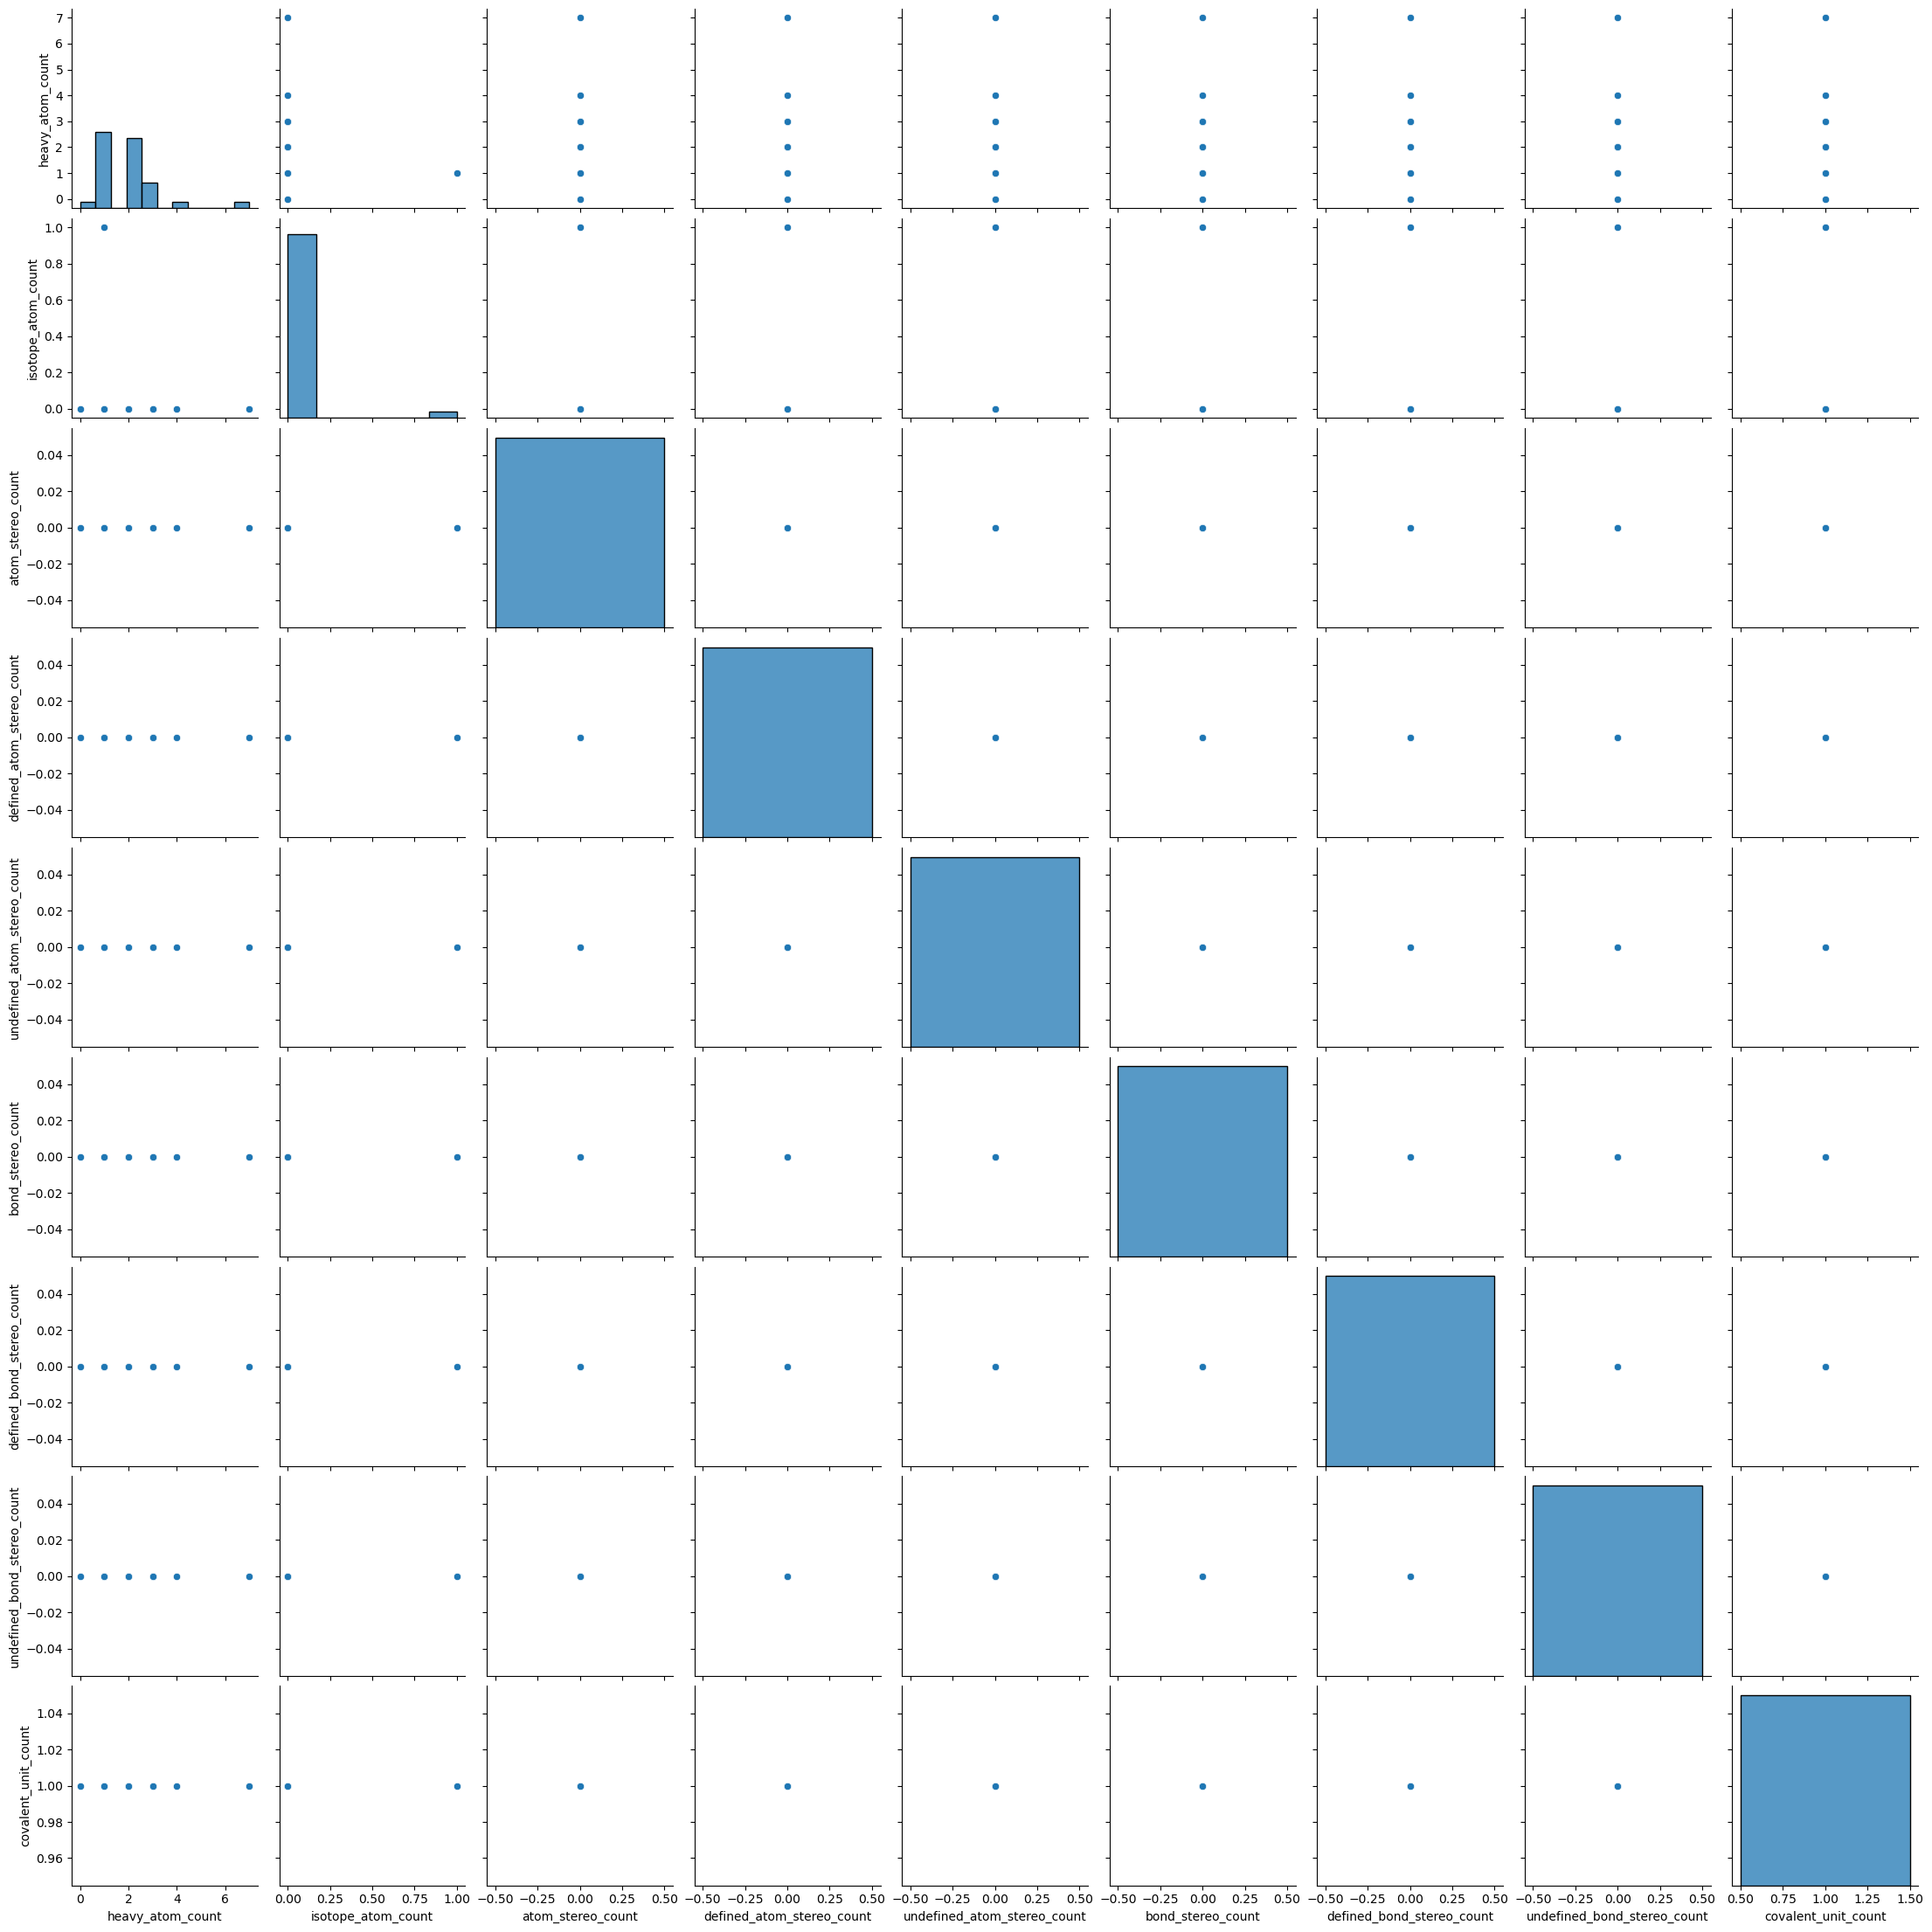

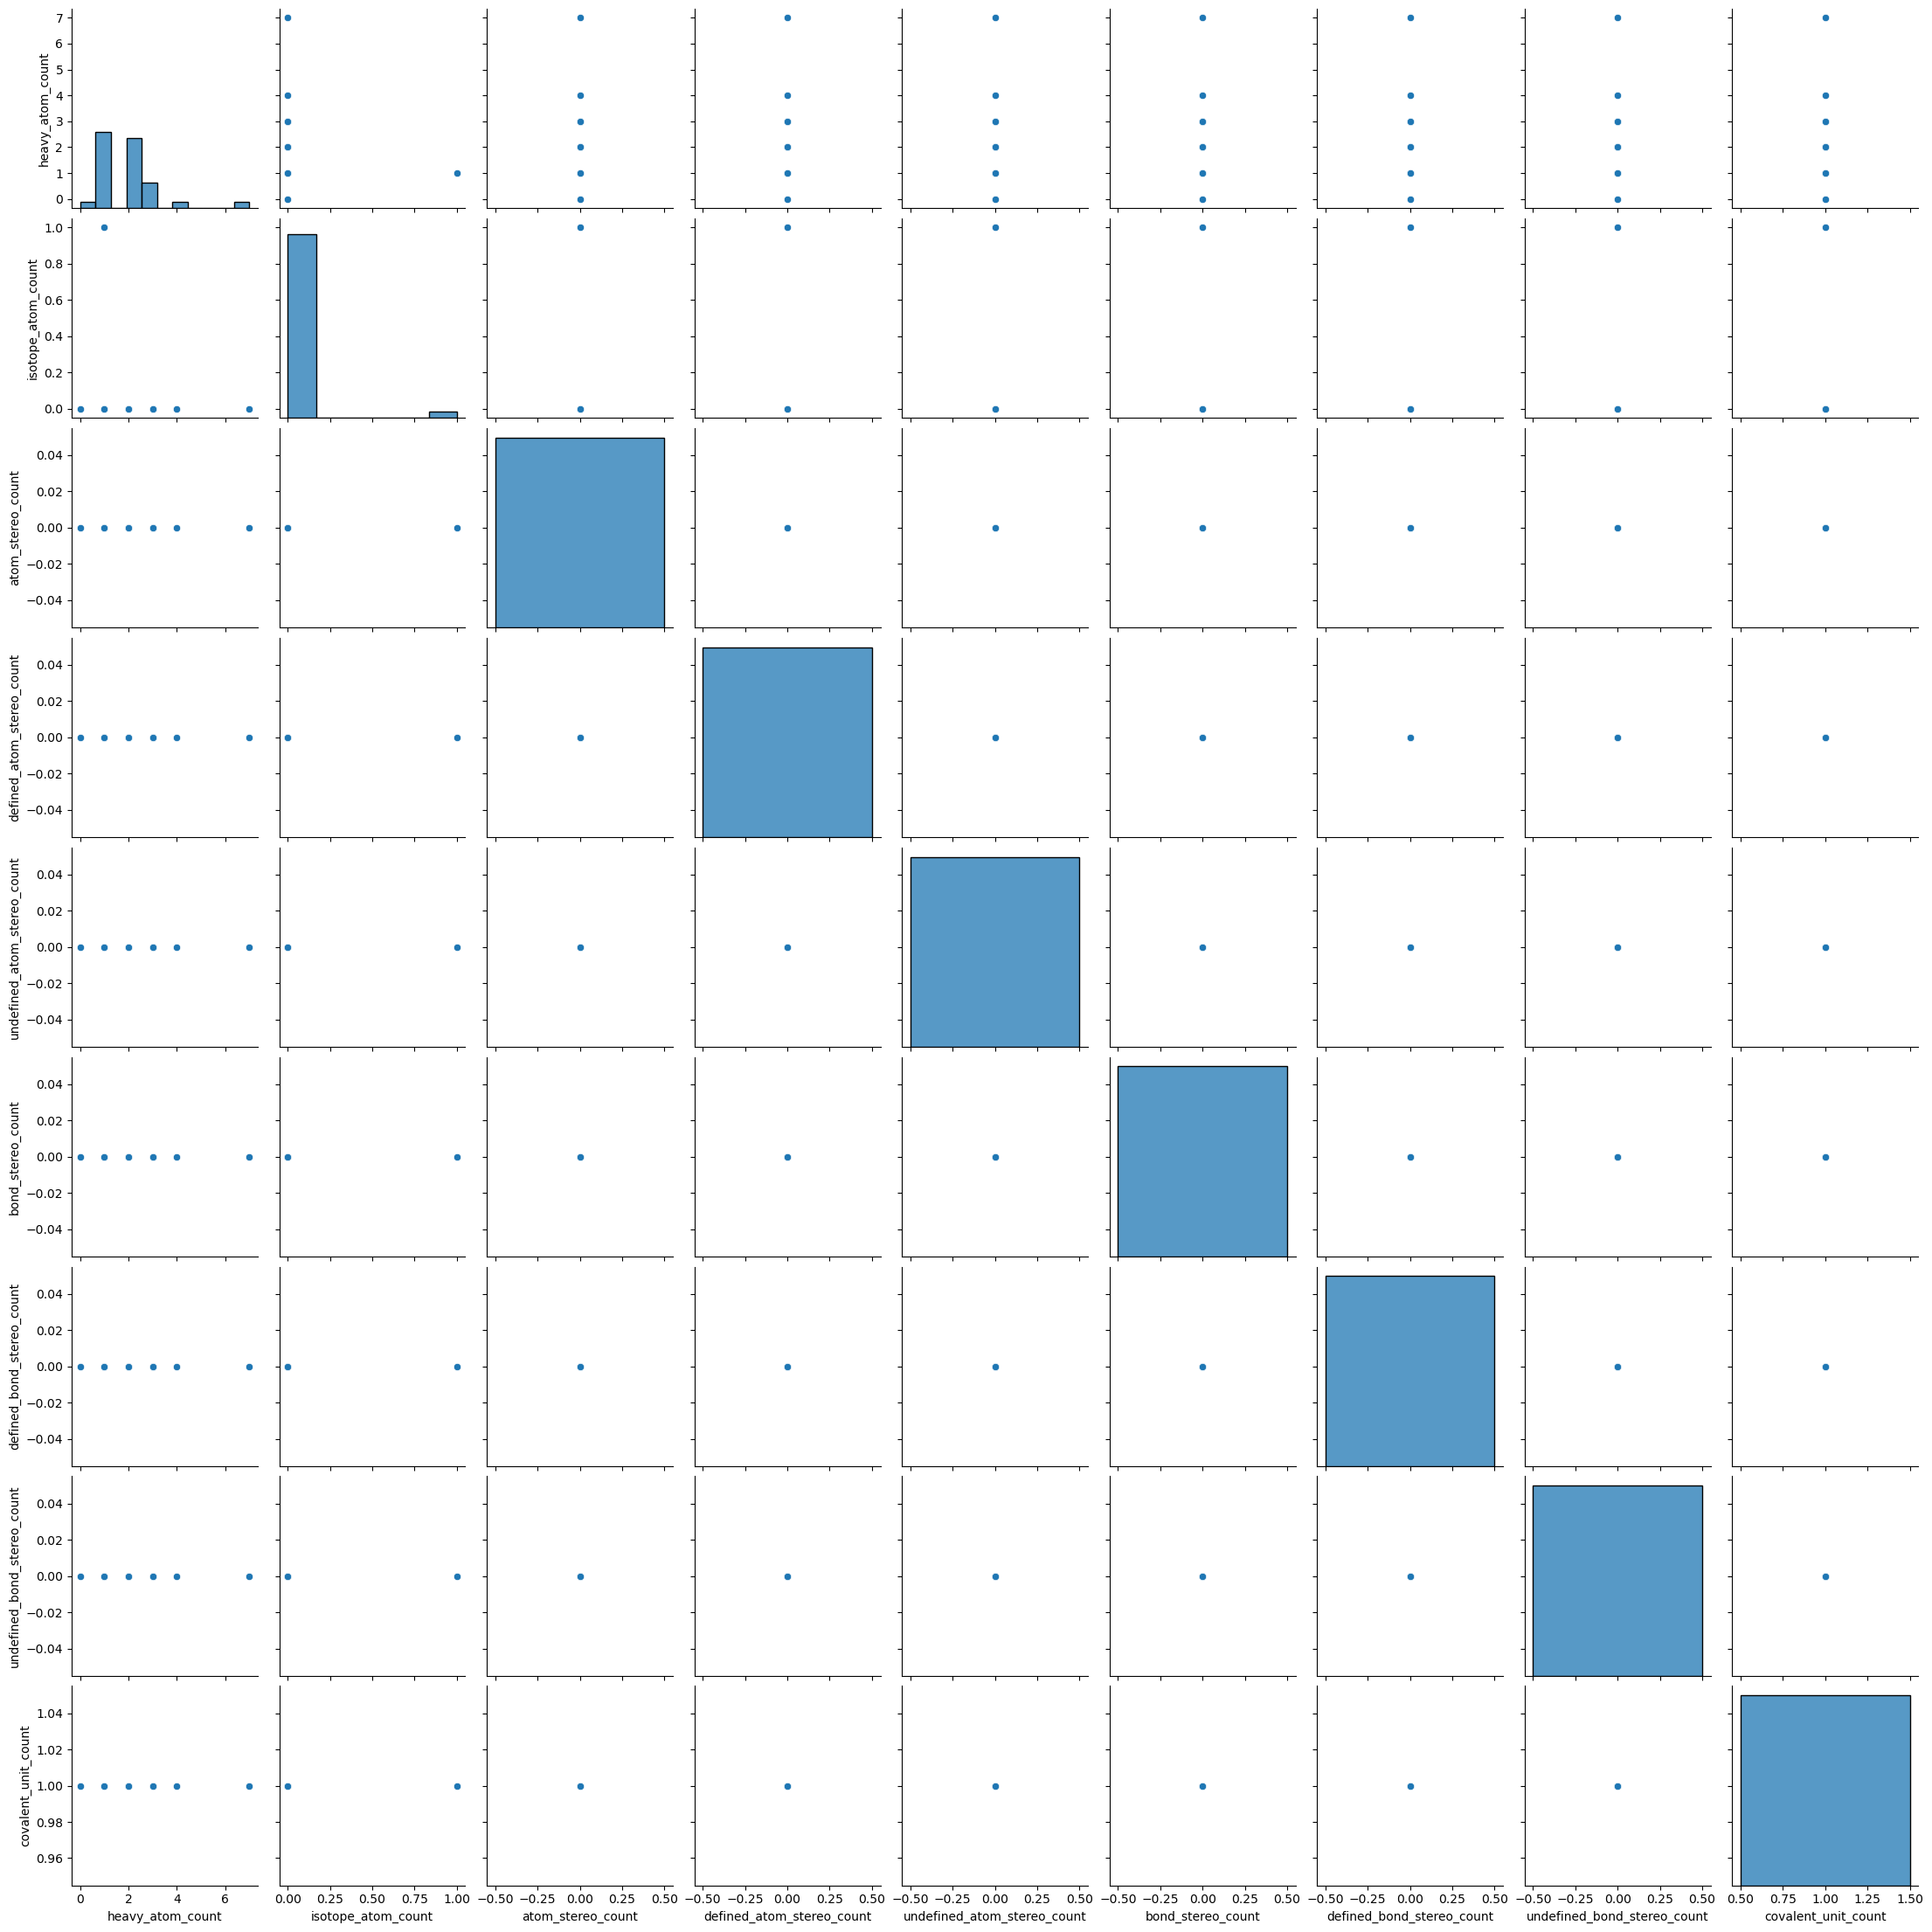

In [42]:
seaborn.pairplot(vdv_const_numbers[vdv_const_numbers.columns[-9:]])

In [ ]:
seaborn.pairplot(vdv_const_numbers[vdv_const_numbers.columns[-9:]])